import de librairies

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

load and explore data

In [3]:
df=pd.read_csv('Task 3 and 4_Loan_Data.csv')


In [5]:
df.shape

(10000, 8)

In [6]:
df.columns

Index(['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

In [7]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [8]:
print(f"\n[3] Summary Statistics:\n{df.describe().round(2)}")
print(f"\n[4] Missing values:\n{df.isnull().sum()}")
print(f"\n[5] Default Rate: {df['default'].mean():.2%}  "
      f"({df['default'].sum()} defaults out of {len(df)} loans)")
 


[3] Summary Statistics:
       customer_id  credit_lines_outstanding  loan_amt_outstanding  \
count     10000.00                  10000.00              10000.00   
mean    4974577.00                      1.46               4159.68   
std     2293889.71                      1.74               1421.40   
min     1000324.00                      0.00                 46.78   
25%     2977661.00                      0.00               3154.24   
50%     4989501.50                      1.00               4052.38   
75%     6967210.25                      2.00               5052.90   
max     8999789.00                      5.00              10750.68   

       total_debt_outstanding     income  years_employed  fico_score   default  
count                10000.00   10000.00        10000.00    10000.00  10000.00  
mean                  8718.92   70039.90            4.55      637.56      0.19  
std                   6627.16   20072.21            1.57       60.66      0.39  
min                 

feature engineering

In [11]:
df['debt_to_income']=df['total_debt_outstanding']/(df['income'] + 1 )
df['loan_to_income']=df["loan_amt_outstanding"]/(df['income']+1)
df['debt_to_loan']=df['total_debt_outstanding']/df['loan_amt_outstanding']

define features and target

In [12]:
FEATURES = [
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score",
    "debt_to_income",
    "loan_to_income",
    "debt_to_loan"
]
 
X = df[FEATURES]
y = df["default"]

train and test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    
)
 
print(f"\n[7] Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"    Train default rate: {y_train.mean():.2%}")
print(f"    Test  default rate: {y_test.mean():.2%}")


[7] Train size: 8,000  |  Test size: 2,000
    Train default rate: 18.51%
    Test  default rate: 18.50%


feature scaling

In [14]:
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

model de logistic regression

In [15]:
 
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced", 
    random_state=42,
    solver="lbfgs"
)
model.fit(X_train_sc, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cross validation

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_auc= cross_val_score(model, X_train_sc, y_train,cv=cv , scoring='roc_auc')


In [17]:

print(f"    Scores : {cv_auc.round(4)}")
print(f"    Mean   : {cv_auc.mean():.4f}  |  Std: {cv_auc.std():.4f}")

    Scores : [1.     1.     1.     1.     0.9999]
    Mean   : 1.0000  |  Std: 0.0000


evaluate on test data

In [18]:
y_pred       = model.predict(X_test_sc)
y_pred_proba = model.predict_proba(X_test_sc)[:, 1] 
 
auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
 
# Kolmogorov-Smirnov statistic
ks_stat = max(tpr - fpr)
 
print(f"\n[10] Test Set Performance:")
print(f"    AUC-ROC : {auc:.4f}")
print(f"    KS Stat : {ks_stat:.4f}")
print(f"\n    Classification Report:\n{classification_report(y_test, y_pred)}") 
 


[10] Test Set Performance:
    AUC-ROC : 1.0000
    KS Stat : 0.9975

    Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.98      1.00      0.99       370

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000



expect loss function

In [20]:
recoveryrate= 0.10
LGD=1-recoveryrate

def predict_expected_loss(
     credit_lines_outstanding: int,
    loan_amt_outstanding:     float,
    total_debt_outstanding:   float,
    income:                   float,
    years_employed:           int,
    fico_score:               int
) -> dict :

    debt_to_income = total_debt_outstanding / (income + 1)
    loan_to_income = loan_amt_outstanding   / (income + 1)
    debt_to_loan   = total_debt_outstanding / (loan_amt_outstanding + 1)
 
    raw = np.array([[
        credit_lines_outstanding,
        loan_amt_outstanding,
        total_debt_outstanding,
        income,
        years_employed,
        fico_score,
        debt_to_income,
        loan_to_income,
        debt_to_loan
    ]])
 
    raw_scaled = scaler.transform(raw)
    pd_value   = model.predict_proba(raw_scaled)[0, 1]
    ead        = loan_amt_outstanding
    el         = pd_value * LGD * ead

    return {
        'probability of default': round(pd_value,6),
        'exposure at default': round(ead,2),
        'loss given default': LGD,
        'expected loss': round(el,2)

    }

apply EL to full test set

In [21]:
test_df = X_test.copy()
test_df["actual_default"] = y_test.values
test_df["PD"]             = y_pred_proba
test_df["EAD"]            = test_df["loan_amt_outstanding"]
test_df["LGD"]            = LGD
test_df["Expected_Loss"]  = test_df["PD"] * test_df["LGD"] * test_df["EAD"]
 
total_exposure       = test_df["EAD"].sum()
total_expected_loss  = test_df["Expected_Loss"].sum()
actual_loss          = test_df.loc[test_df["actual_default"] == 1, "EAD"].sum() * LGD
 
print(f"\n[12] Portfolio Expected Loss Summary (Test Set — {len(test_df):,} loans):")
print(f"    Total Loan Exposure    : ${total_exposure:>15,.2f}")
print(f"    Total Expected Loss    : ${total_expected_loss:>15,.2f}")
print(f"    Actual Loss (realized) : ${actual_loss:>15,.2f}")
print(f"    EL as % of Exposure    : {total_expected_loss / total_exposure:.2%}")


[12] Portfolio Expected Loss Summary (Test Set — 2,000 loans):
    Total Loan Exposure    : $   8,373,362.00
    Total Expected Loss    : $   1,553,238.46
    Actual Loss (realized) : $   1,483,568.07
    EL as % of Exposure    : 18.55%


single borrower demo

In [22]:
print("\n[13] Single Borrower Demonstration:")
 
borrower_a = predict_expected_loss(
    credit_lines_outstanding=2,
    loan_amt_outstanding=10_000,
    total_debt_outstanding=25_000,
    income=55_000,
    years_employed=3,
    fico_score=610
)
print(f"\n  Borrower A (moderate risk — FICO 610, moderate debt):")
for k, v in borrower_a.items():
    print(f"    {k:<30}: {v}")
 
borrower_b = predict_expected_loss(
    credit_lines_outstanding=0,
    loan_amt_outstanding=5_000,
    total_debt_outstanding=3_000,
    income=90_000,
    years_employed=8,
    fico_score=760
)
print(f"\n  Borrower B (low risk — FICO 760, high income):")
for k, v in borrower_b.items():
    print(f"    {k:<30}: {v}")
 
borrower_c = predict_expected_loss(
    credit_lines_outstanding=5,
    loan_amt_outstanding=18_000,
    total_debt_outstanding=60_000,
    income=30_000,
    years_employed=1,
    fico_score=450
)
print(f"\n  Borrower C (high risk — FICO 450, high debt-to-income):")
for k, v in borrower_c.items():
    print(f"    {k:<30}: {v}")


[13] Single Borrower Demonstration:

  Borrower A (moderate risk — FICO 610, moderate debt):
    probability of default        : 1.0
    exposure at default           : 10000
    loss given default            : 0.9
    expected loss                 : 9000.0

  Borrower B (low risk — FICO 760, high income):
    probability of default        : 0.0
    exposure at default           : 5000
    loss given default            : 0.9
    expected loss                 : 0.0

  Borrower C (high risk — FICO 450, high debt-to-income):
    probability of default        : 1.0
    exposure at default           : 18000
    loss given default            : 0.9
    expected loss                 : 16200.0


plot


[14] Plots saved to: loan_default_results.png

  DONE


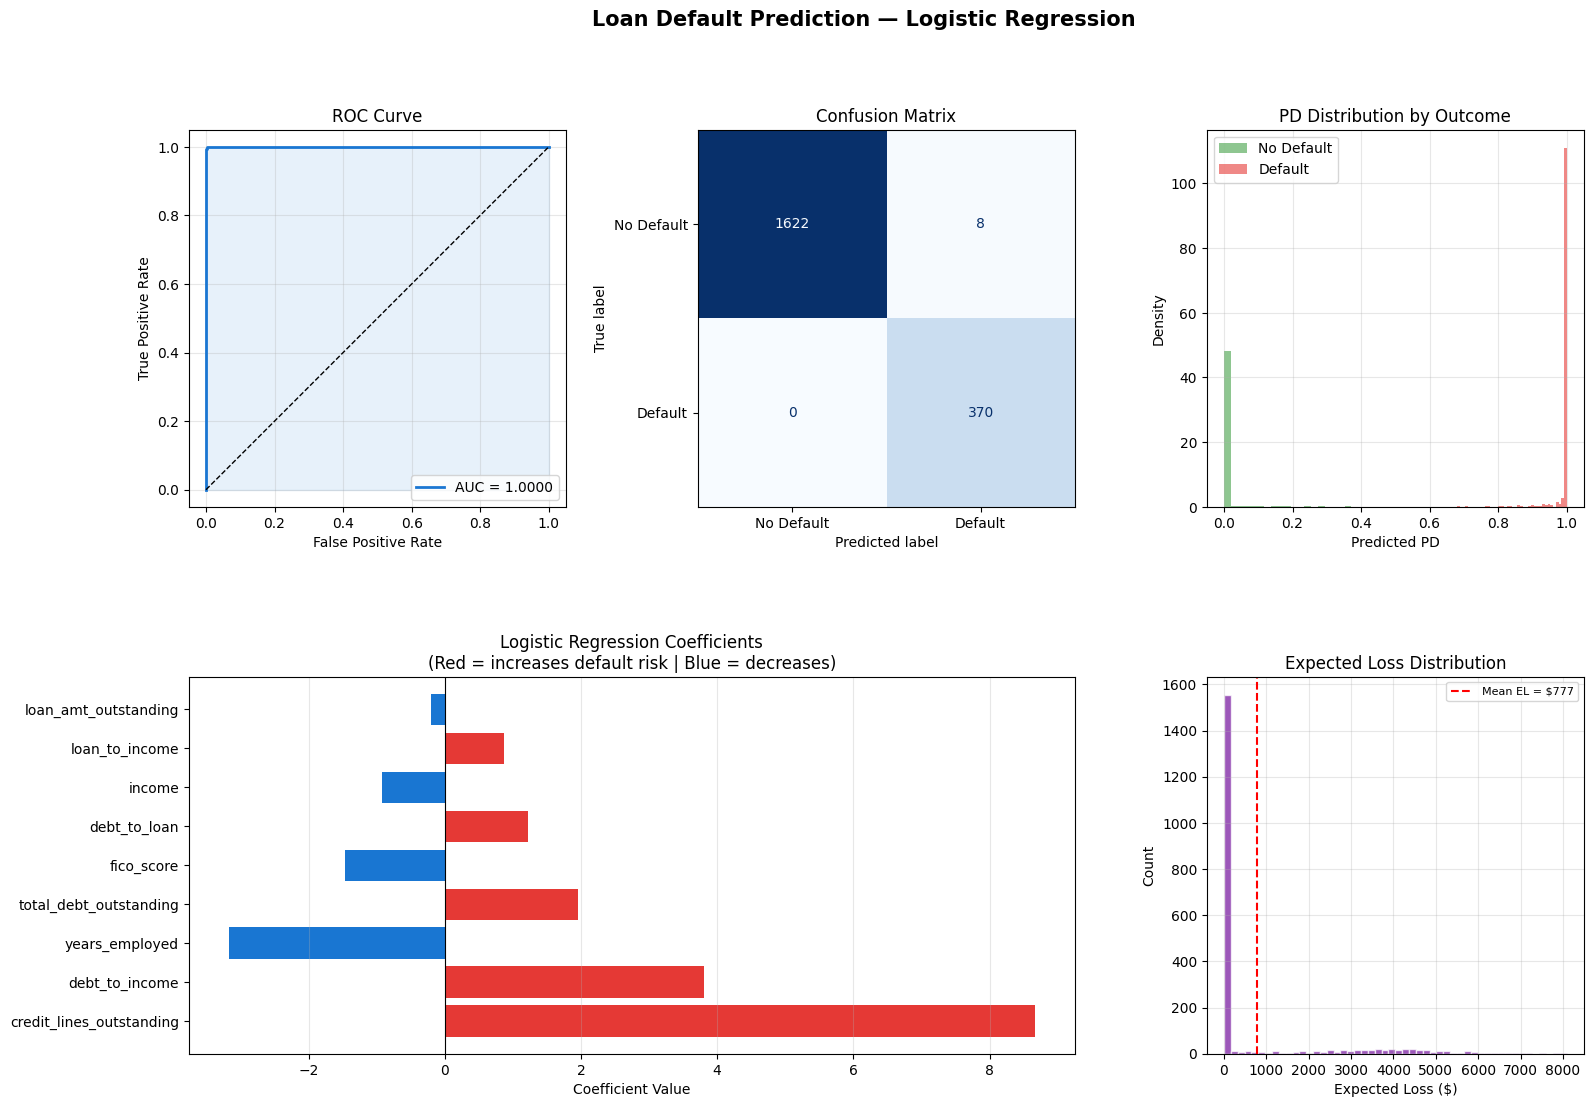

In [24]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Loan Default Prediction — Logistic Regression", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, color="#1976D2", lw=2, label=f"AUC = {auc:.4f}")
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.fill_between(fpr, tpr, alpha=0.1, color="#1976D2")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)
 
# — Confusion Matrix —
ax2 = fig.add_subplot(gs[0, 1])
cm  = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax2, colorbar=False, cmap="Blues")
ax2.set_title("Confusion Matrix")
 
# — PD Distribution by Outcome —
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(test_df.loc[test_df["actual_default"] == 0, "PD"],
         bins=40, alpha=0.6, color="#43A047", label="No Default", density=True)
ax3.hist(test_df.loc[test_df["actual_default"] == 1, "PD"],
         bins=40, alpha=0.6, color="#E53935", label="Default",    density=True)
ax3.set_xlabel("Predicted PD")
ax3.set_ylabel("Density")
ax3.set_title("PD Distribution by Outcome")
ax3.legend()
ax3.grid(alpha=0.3)
 
# — Feature Coefficients —
ax4 = fig.add_subplot(gs[1, 0:2])
colors = ["#E53935" if c > 0 else "#1976D2" for c in coef_df["Coefficient"]]
ax4.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax4.axvline(0, color="black", lw=0.8)
ax4.set_xlabel("Coefficient Value")
ax4.set_title("Logistic Regression Coefficients\n(Red = increases default risk | Blue = decreases)")
ax4.grid(alpha=0.3, axis="x")
 
# — Expected Loss Distribution —
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(test_df["Expected_Loss"], bins=50, color="#7B1FA2", alpha=0.75, edgecolor="white")
ax5.axvline(test_df["Expected_Loss"].mean(), color="red", lw=1.5,
            linestyle="--", label=f"Mean EL = ${test_df['Expected_Loss'].mean():,.0f}")
ax5.set_xlabel("Expected Loss ($)")
ax5.set_ylabel("Count")
ax5.set_title("Expected Loss Distribution")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)
 
plt.savefig("loan_default_results.png", dpi=150, bbox_inches="tight")
print("\n[14] Plots saved to: loan_default_results.png")
print("\n" + "=" * 60)
print("  DONE")
print("=" * 60)
 